In [1]:
### Preamples ###
import numpy as np
import matplotlib.pyplot as plt
import random
from numba import njit

random.seed(13)

In [7]:
@njit
def heston_returns(V0, N, mu, theta, kappa, sigma_V, rho, h, n_sub):
    
    dt = h / n_sub
    sqrt_dt = dt ** 0.5
    c = (1 - rho ** 2) ** 0.5 
    
    returns = np.empty(N)
  
    Vt = V0
    log_ret = 0
    
    for n in range(N):
        log_ret = 0
        for _ in range(n_sub):
            z1 = np.random.normal(0, 1)
            z2 = np.random.normal(0, 1)
            
            dB1 = sqrt_dt * z1
            dB2 = sqrt_dt * (rho * z1 + c * z2) 
            
            Vt_pos = Vt if Vt > 0 else 0 # ensure variance is non-negative for the price update
            
            log_ret += (mu - 0.5 * Vt) * dt + Vt_pos ** 0.5 * dB1 # log return increment
            
            Vt = Vt_pos + kappa * (theta - Vt_pos)* dt + sigma_V * Vt_pos ** 0.5 * dB2  # variance process
            
        returns[n] = log_ret
        
    return returns 

In [2]:
def h_tilde(kappa, h):
    "h_tidle = (1 - exp(-kappa * h)) / kappa"
    return (1 - np.exp(-kappa * h)) / kappa

def lagm_cov_est(ret, m):
    
    N = len(ret)
    Ybar = np.mean(ret)
    
    cov = np.sum((ret[:N-m] - Ybar) * (ret[m:] - Ybar)) / (N - m)
    return cov

def estimate_kappa(ret, h , lag_M = 10):
    N = len(ret)
    
    lag1 = lagm_cov_est(ret, 1)
    
    kappa_sum = 0
    
    for m in range(2, lag_M + 1):
        lagm = lagm_cov_est(ret, m)
        
        if lagm == 0 or np.sign(lag1) != np.sign(lagm):
            continue
        
        ratio = lag1 / lagm
        if ratio <= 0 or not np.isfinite(np.log(ratio)):
            continue
        
        k_est = np.log(ratio) / ((m-1) * h)
        if not np.isfinite(k_est) or k_est <= 0:
            continue
        kappa_sum += k_est
        
    kappa = kappa_sum / (lag_M - 1)
    return kappa

def estimate_moments(ret):
    n = len(ret)
    Ybar = np.mean(ret)
    mean = Ybar
    var = np.var(ret, ddof = 1)
    lag1 = lagm_cov_est(ret, 1) 
    lag2 = lagm_cov_est(ret, 2)

    y2 = ret[:-1]**2
    y2d = y2 - np.mean(y2)
    yn1d = ret[1:] - np.mean(ret[1:])
    cross = np.mean(y2d * yn1d)
    
    return np.array([mean, var, lag1, lag2, cross])

def moments(mu, theta, kappa, sigma_V, rho, h):
    """Returns first five moments of the log returns of the Heston model."""
    ht = h_tilde(kappa, h)
    ek = np.exp(-kappa * h)
    
    # First moment (mean), follows from Theorem 2.1
    
    mean = h * (mu  - 0.5 * theta)
    
    # Second moment (variance), follows from Theorem 2.2
    
    var = theta * (h - ht) * ( (sigma_V**2)/ (4 * (kappa ** 2)) 
                              - (rho * sigma_V) / kappa) + theta * h
    
    # Third moment (lag-1 autocovariance), follows from Theorem 2.3
    
    lag1 = (((ht ** 2) * theta * (sigma_V)) / 2 ) * ( (sigma_V) / (4 * kappa) - rho)
    
    # Fourth moment (lag-2 autocovariance), follows from Theorem 2.4
    
    lag2 = ek * lag1
    
    
    # Fifth moment (Cross variance bewteen squared retursn and future returns),
    # follows from Theorem 2.5
    
    term1 = ((theta * (sigma_V ** 4) / ( 8 * kappa **3))) * ht * (h * ek - ht)
    
    term2 = ht**2 * ((theta * sigma_V ** 2) / (4 * kappa) * mu * h
                     - (theta ** 2 * sigma_V ** 2) / (8 * kappa) * h
                     - (theta * sigma_V ** 2 ) / (4 * kappa))
    
    term3  = (-rho * sigma_V / 2 * ht) * (
        (3 * sigma_V**2 / (2 * kappa**2) - 2 * rho * sigma_V / kappa)
        * theta * (h * ek - ht)
        + (2 * mu * theta - theta**2) * h * ht
)
    
    cross = term1 + term2 - term3
    
    return mean, var, lag1, lag2, cross

In [10]:
def estimate_heston_from_returns(ret, h, verbose= False):
    N = len(ret)
    mean_e, var_e, lag1_e, lag2_e, cross_e = estimate_moments(ret)
    
    kappa = estimate_kappa(ret, h)
    
    ht = h_tilde(kappa, h)
    
    ek = np.exp(-kappa * h)
    
    dh = h * ek - ht
    
    theta = var_e / h  - (2* (h-ht) / (h * kappa * ht ** 2)) * lag1_e 
    
    mu = mean_e / h + theta / 2
    
    num   = (4*kappa*mean_e
             + (8*dh/(theta*ht**3))*lag1_e
             - 2*kappa*cross_e/lag1_e)
    den   = (theta*ht**2/(2*lag1_e) - dh/(kappa*ht))

    sigma_sq = num / den
    sigma_V = sigma_sq**0.5
    
    rho = np.clip(sigma_V/(4*kappa) - (2/(theta*sigma_V*ht**2))*lag1_e,
                  -0.999, 0.999)
    
    if verbose:
        print( f"  κ̂    = {kappa:.4f}")
        print(f"  θ̂    = {theta:.4f}")
        print(f"  μ̂    = {mu:.4f}")
        print(f"  σ̂_V  = {sigma_V:.6f}")
        print(f"  ρ̂    = {rho:.6f}")
    

    return {'mu': mu, 'theta': theta, 'kappa': kappa,
            'sigma_V': sigma_V, 'rho': rho}
    

In [ ]:
def experiment_feller(TRUE_base, V0, h, n_sub, n_rep=100, N=int(400_000)):
    """
    Tests estimator performance as Feller condition is approached.
    Reports ALL parameters, failure rate, and variance process behaviour.
    """
    sigma_V_vals = [0.05, 0.10, 0.20, 0.30, 0.35, 0.40, 0.50]
    keys         = ['mu', 'theta', 'kappa', 'sigma_V', 'rho']

    results = []

    for sigma_V in sigma_V_vals:
        TRUE         = {**TRUE_base, 'sigma_V': sigma_V}
        feller_ratio = 2*TRUE['kappa']*TRUE['theta'] / sigma_V**2
        satisfied    = feller_ratio >= 1

        estimates    = {k: [] for k in keys}
        failed       = 0
        v_zero_count = 0   # how often V_t hits zero during simulation

        for r in range(n_rep):
            ret = heston_returns(V0, N,
                                 TRUE['mu'], TRUE['theta'], TRUE['kappa'],
                                 sigma_V, TRUE['rho'], h, n_sub)

            # Check if variance process hit zero during simulation
            if np.any(np.abs(ret) < 1e-10):
                v_zero_count += 1

            try:
                est = estimate_heston_from_returns(ret, h)
                for k in keys:
                    estimates[k].append(est[k])
            except Exception:
                failed += 1

        row = {
            'sigma_V'     : sigma_V,
            'feller_ratio': feller_ratio,
            'satisfied'   : satisfied,
            'failed'      : failed,
            'v_zero_pct'  : v_zero_count / n_rep * 100,
        }
        for k in keys:
            vals         = np.array(estimates[k])
            row[f'bias_{k}'] = vals.mean() - TRUE[k] if len(vals) > 0 else np.nan
            row[f'std_{k}']  = vals.std()             if len(vals) > 0 else np.nan
            row[f'rmse_{k}'] = np.sqrt((vals.mean()-TRUE[k])**2 + vals.var()) \
                                if len(vals) > 0 else np.nan
        results.append(row)

    # ── Print bias table for all parameters ───────────────────────────────
    print(f"\n{'σ_V':<6s}  {'Feller':>8s}  {'OK':>4s}  " +
          "  ".join(f"{'bias('+k+')':>10s}" for k in keys) +
          f"  {'Failed':>7s}  {'V→0%':>6s}")
    print("-" * 95)
    for r in results:
        print(f"  {r['sigma_V']:<4.3f}  {r['feller_ratio']:>8.3f}  "
              f"{'✓' if r['satisfied'] else '✗':>4s}  " +
              "  ".join(f"{r['bias_'+k]:>10.4f}" for k in keys) +
              f"  {r['failed']:>7d}  {r['v_zero_pct']:>5.1f}%")

    # ── Print RMSE table ───────────────────────────────────────────────────
    print(f"\n{'σ_V':<6s}  {'Feller':>8s}  " +
          "  ".join(f"{'RMSE('+k+')':>10s}" for k in keys))
    print("-" * 75)
    for r in results:
        print(f"  {r['sigma_V']:<4.3f}  {r['feller_ratio']:>8.3f}  " +
              "  ".join(f"{r['rmse_'+k]:>10.4f}" for k in keys))

    # ── Plot ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle('Feller Condition Experiment', fontsize=12, fontweight='bold')
    axes = axes.flatten()

    sigma_V_plot  = [r['sigma_V']      for r in results]
    feller_plot   = [r['feller_ratio'] for r in results]

    for i, k in enumerate(keys):
        ax   = axes[i]
        bias = [r[f'bias_{k}'] for r in results]
        rmse = [r[f'rmse_{k}'] for r in results]

        ax.plot(sigma_V_plot, bias, 'o-', color='#1565C0',
                lw=2, label='bias', zorder=4)
        ax.plot(sigma_V_plot, rmse, 's--', color='#C62828',
                lw=2, label='RMSE', zorder=4)
        ax.axhline(0, color='black', lw=0.8, ls=':')

        # Shade Feller-violated region
        feller_threshold = np.sqrt(2*TRUE_base['kappa']*TRUE_base['theta'])
        ax.axvspan(feller_threshold, max(sigma_V_plot),
                   color='red', alpha=0.08, label='Feller violated')
        ax.axvline(feller_threshold, color='red', lw=1.5, ls='--', alpha=0.5)

        ax.set_title(k)
        ax.set_xlabel(r'$\sigma_V$')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, ls=':')

    # Panel 6 — failure rate and V→0
    ax = axes[5]
    failed_pct = [r['failed']/n_rep*100   for r in results]
    vzero_pct  = [r['v_zero_pct']         for r in results]
    ax.plot(sigma_V_plot, failed_pct, 'o-', color='#C62828',
            lw=2, label='Failed (%)')
    ax.plot(sigma_V_plot, vzero_pct,  's--', color='#E65100',
            lw=2, label='V→0 (%)')
    ax.axvline(feller_threshold, color='red', lw=1.5, ls='--', alpha=0.5)
    ax.axvspan(feller_threshold, max(sigma_V_plot),
               color='red', alpha=0.08)
    ax.set_title('Failure rate & V→0')
    ax.set_xlabel(r'$\sigma_V$')
    ax.set_ylabel('%')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, ls=':')

    plt.tight_layout()
    plt.savefig('feller_experiment.png', dpi=150, bbox_inches='tight')
    plt.show()

    return results


σ_V       Feller    OK    bias(mu)  bias(theta)  bias(kappa)  bias(sigma_V)   bias(rho)   Failed    V→0%
-----------------------------------------------------------------------------------------------
  0.050    20.000     ✓      0.0000     -0.0003      0.0072      0.0015     -0.0078        0    0.0%
  0.100     5.000     ✓     -0.0001     -0.0004      0.0007     -0.0003     -0.0116        0    0.0%
  0.200     1.250     ✓     -0.0004     -0.0007      0.0008     -0.0000     -0.0098        0    0.0%
  0.300     0.556     ✗     -0.0007      0.0039      0.0012     -0.0007     -0.0161        0    0.0%
  0.350     0.408     ✗     -0.0008      0.0109      0.0022     -0.0011     -0.0215        0    0.0%
  0.400     0.312     ✗     -0.0008      0.0226      0.0031      0.0006     -0.0118        0    0.0%
  0.500     0.200     ✗     -0.0011      0.0540      0.0056      0.0009     -0.0140        0    0.0%

σ_V       Feller    RMSE(mu)  RMSE(theta)  RMSE(kappa)  RMSE(sigma_V)   RMSE(rho)
--------

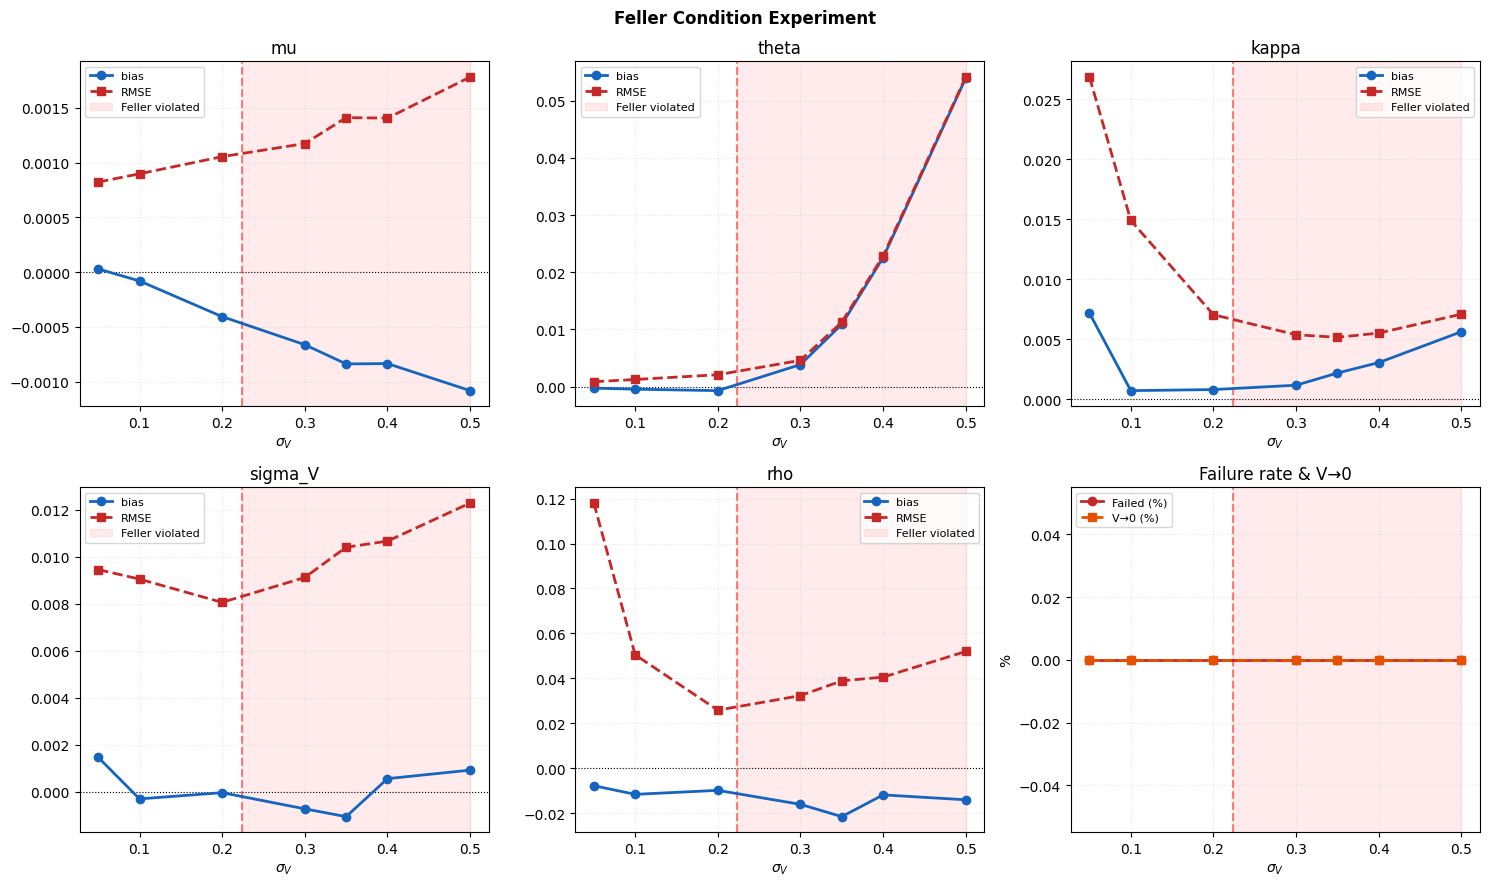

In [37]:
TRUE_base = dict(mu=0.125, kappa=0.1, theta=0.25, sigma_V=0.1, rho=-0.7)
V0 = TRUE_base['theta']    # start in stationarity
h = 1.0              # annual observation interval
N = int(400_000)          # number of observations
n_sub = int(20)              # sub-steps per interval — critical for stability

results = experiment_feller(TRUE_base, V0, h, n_sub, n_rep=100, N=int(400_000))

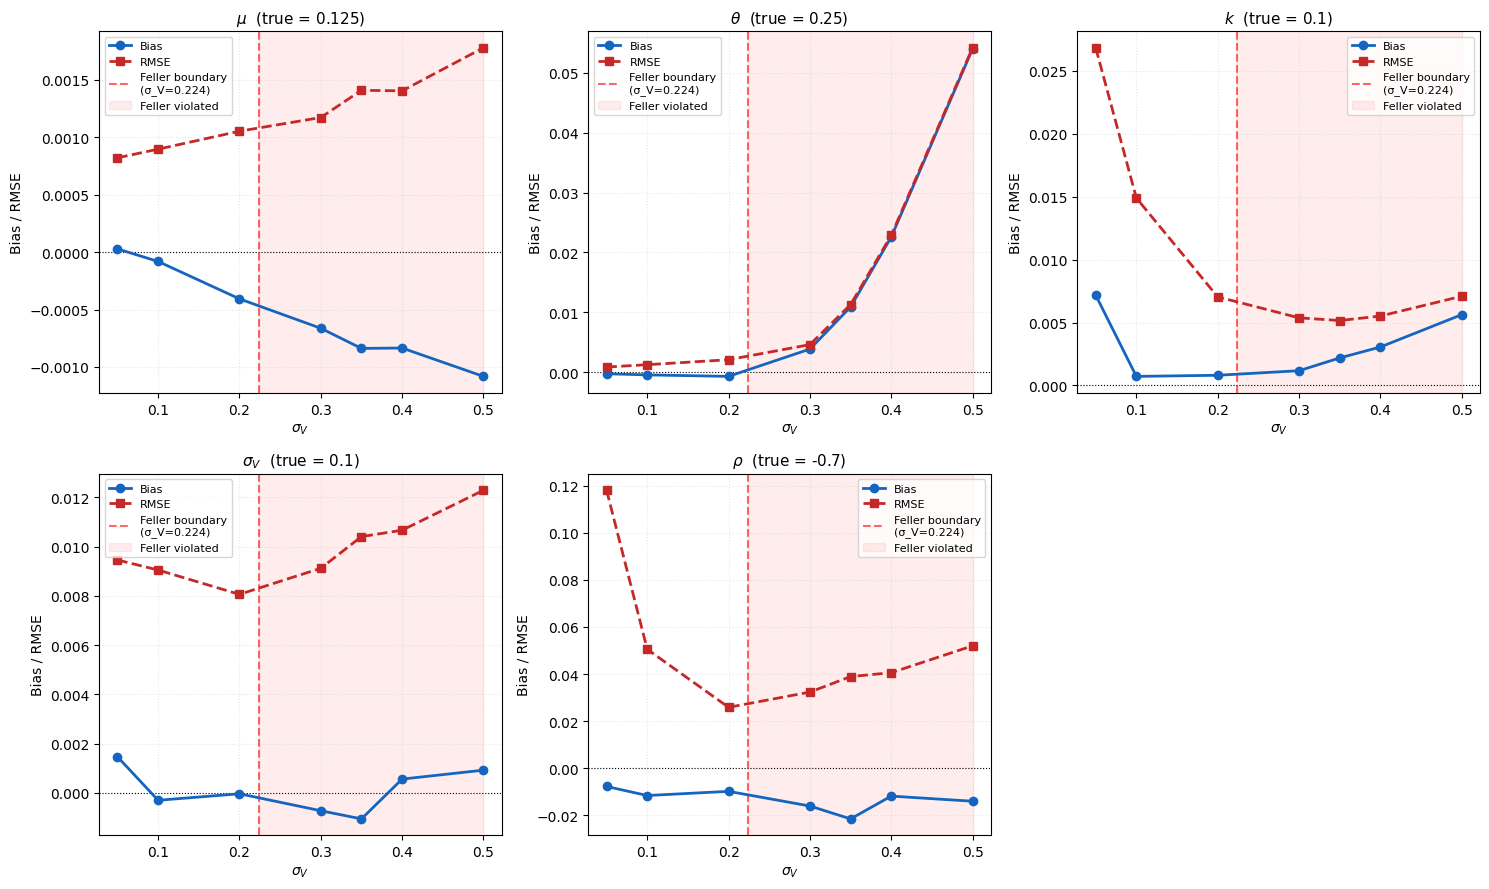

Saved to feller_bias_rmse.png


In [39]:
keys   = ['mu', 'theta', 'kappa', 'sigma_V', 'rho']
labels = [r'$\mu$', r'$\theta$', r'$k$', r'$\sigma_V$', r'$\rho$']

TRUE_base        = dict(mu=0.125, kappa=0.1, theta=0.25, sigma_V=0.1, rho=-0.7)
feller_threshold = np.sqrt(2*TRUE_base['kappa']*TRUE_base['theta'])
sigma_V_plot     = [r['sigma_V'] for r in results]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (k, label) in enumerate(zip(keys, labels)):
    ax   = axes[i]
    bias = [r[f'bias_{k}'] for r in results]
    rmse = [r[f'rmse_{k}'] for r in results]

    ax.plot(sigma_V_plot, bias, 'o-', color='#1565C0',
            lw=2, ms=6, label='Bias', zorder=4)
    ax.plot(sigma_V_plot, rmse, 's--', color='#C62828',
            lw=2, ms=6, label='RMSE', zorder=4)
    ax.axhline(0, color='black', lw=0.8, ls=':')

    # Feller boundary
    ax.axvline(feller_threshold, color='red', lw=1.5,
               ls='--', alpha=0.6, label=f'Feller boundary\n(σ_V={feller_threshold:.3f})')
    ax.axvspan(feller_threshold, max(sigma_V_plot),
               color='red', alpha=0.07, label='Feller violated')

    # Mark the true parameter value
    true_val = TRUE_base.get(k, None)
    if true_val is not None:
        ax.set_title(f'{label}  (true = {true_val})', fontsize=11)
    else:
        ax.set_title(label, fontsize=11)

    ax.set_xlabel(r'$\sigma_V$', fontsize=10)
    ax.set_ylabel('Bias / RMSE', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, ls=':')

# Hide the unused 6th panel
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('feller_bias_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to feller_bias_rmse.png")

In [ ]:
def experiment_feller_v2(TRUE_base, V0, h, n_sub, n_rep=100, N=int(400_000)):

    sigma_V_vals = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.70]
    keys         = ['mu', 'theta', 'kappa', 'sigma_V', 'rho']
    results      = []

    for sigma_V in sigma_V_vals:
        TRUE         = {**TRUE_base, 'sigma_V': sigma_V}
        feller_ratio = 2*TRUE['kappa']*TRUE['theta'] / sigma_V**2
        satisfied    = feller_ratio >= 1

        estimates    = {k: [] for k in keys}
        failed       = 0      # exception raised
        nan_results  = 0      # returned but contained NaN

        for r in range(n_rep):
            ret = heston_returns(V0, N,
                                 TRUE['mu'], TRUE['theta'], TRUE['kappa'],
                                 sigma_V, TRUE['rho'], h, n_sub)
            try:
                est = estimate_heston_from_returns(ret, h, verbose=False)

                if not all(np.isfinite(est[k]) for k in keys):
                    nan_results += 1
                    continue

                for k in keys:
                    estimates[k].append(est[k])

            except Exception:
                failed += 1

        total_invalid = failed + nan_results
        row = {
            'sigma_V'     : sigma_V,
            'feller_ratio': feller_ratio,
            'satisfied'   : satisfied,
            'failed'      : failed,
            'nan_results' : nan_results,
            'total_invalid': total_invalid,
            'v_zero_pct'  : 0.0,
        }
        for k in keys:
            vals = np.array(estimates[k])
            if len(vals) > 0:
                row[f'bias_{k}'] = vals.mean() - TRUE[k]
                row[f'std_{k}']  = vals.std()
                row[f'rmse_{k}'] = np.sqrt((vals.mean()-TRUE[k])**2
                                            + vals.var())
            else:
                for stat in ['bias', 'std', 'rmse']:
                    row[f'{stat}_{k}'] = np.nan
        results.append(row)

    # ── Print tables ───────────────────────────────────────────────────────
    print(f"\n{'σ_V':<6s}  {'Feller':>8s}  {'OK':>4s}  " +
          "  ".join(f"{'bias('+k+')':>10s}" for k in keys) +
          f"  {'Except':>7s}  {'NaN':>6s}  {'Total invalid':>14s}")
    print("-" * 110)

    for r in results:
        print(f"  {r['sigma_V']:<4.3f}  {r['feller_ratio']:>8.3f}  "
              f"{'✓' if r['satisfied'] else '✗':>4s}  " +
              "  ".join(f"{r['bias_'+k]:>10.4f}" for k in keys) +
              f"  {r['failed']:>7d}  {r['nan_results']:>6d}  "
              f"{r['total_invalid']:>7d}/{n_rep} "
              f"({r['total_invalid']/n_rep*100:4.1f}%)")

    print(f"\n{'σ_V':<6s}  {'Feller':>8s}  " +
          "  ".join(f"{'RMSE('+k+')':>10s}" for k in keys))
    print("-" * 75)
    for r in results:
        print(f"  {r['sigma_V']:<4.3f}  {r['feller_ratio']:>8.3f}  " +
              "  ".join(f"{r['rmse_'+k]:>10.4f}" for k in keys))

    return results

In [ ]:
TRUE_base = dict(mu=0.125, kappa=0.1, theta=0.25, sigma_V=0.1, rho=-0.7)
V0 = TRUE_base['theta']    # start in stationarity
h = 1.0              # annual observation interval
N = int(400_000)          # number of observations
n_sub = int(20)              # sub-steps per interval — critical for stability

results = experiment_feller_v2(TRUE_base, V0, h, n_sub, n_rep=100, N=int(50_000))


σ_V       Feller    OK    bias(mu)  bias(theta)  bias(kappa)  bias(sigma_V)   bias(rho)   Except     NaN   Total invalid
--------------------------------------------------------------------------------------------------------------
  0.150     2.222     ✓     -0.0002     -0.0009      0.0003     -0.0021     -0.0285        0       0        0/100 ( 0.0%)
  0.200     1.250     ✓     -0.0001     -0.0001     -0.0010     -0.0046     -0.0200        0       0        0/100 ( 0.0%)
  0.250     0.800     ✗     -0.0008     -0.0004      0.0013      0.0001     -0.0191        0       0        0/100 ( 0.0%)
  0.300     0.556     ✗     -0.0007      0.0040      0.0025     -0.0015     -0.0297        0       0        0/100 ( 0.0%)
  0.350     0.408     ✗     -0.0007      0.0110      0.0036     -0.0007     -0.0278        0       0        0/100 ( 0.0%)
  0.400     0.312     ✗     -0.0009      0.0224      0.0035     -0.0057     -0.0456        0       0        0/100 ( 0.0%)
  0.500     0.200     ✗     -0.0005